
Resumo por estação:
  idChargingStation  n_reuse_events  n_sockets  mean_minutes  median_minutes  \
3         ODV-00044             190          3    289.405439       91.133333   
4         SNT-00187             136          1    128.530637       63.641667   
5         SNT-00188              98          2    355.340476       98.058333   
8         TVR-00032              96          2    379.642188      137.708333   
6         SNT-00189              68          2    503.228431      170.633333   
1         FIG-00042              57          2    699.096199      385.983333   
7         TVR-00031              39          2    803.681624      385.866667   
9         VCT-00061              30          3   1576.211667     1187.558333   
0         FIG-00037              13          3   2267.610256     1509.800000   
2         LSB-01115               2          1     25.308333       25.308333   

   p25_minutes  p75_minutes  p90_minutes  max_minutes  
3    30.979167   302.166667   923.860000  

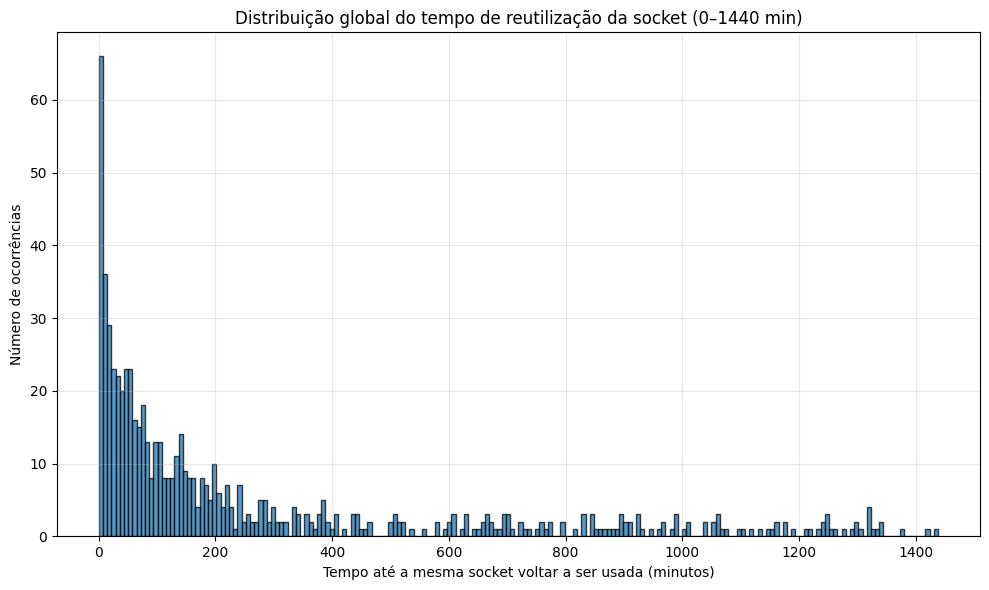

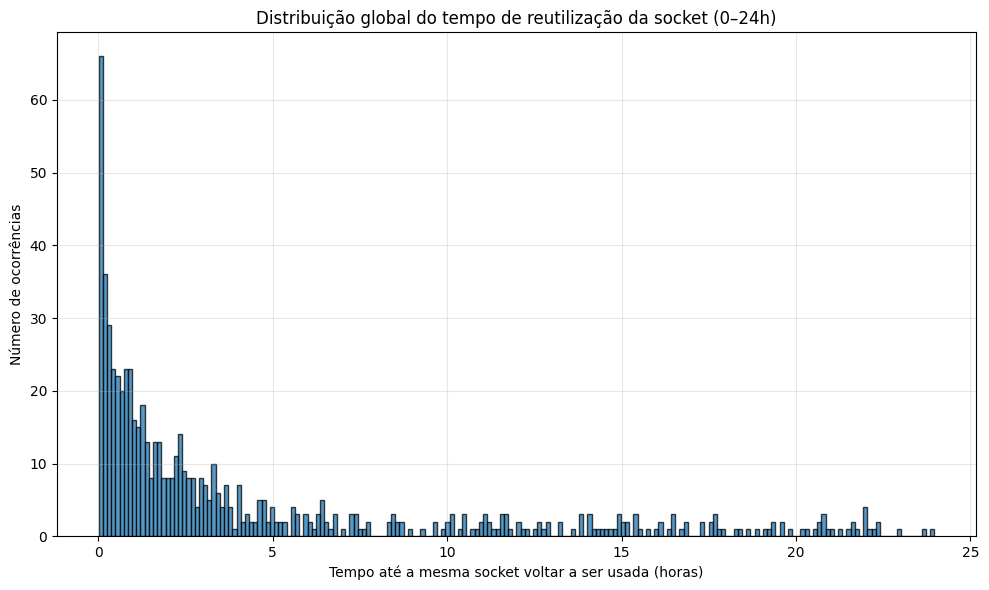

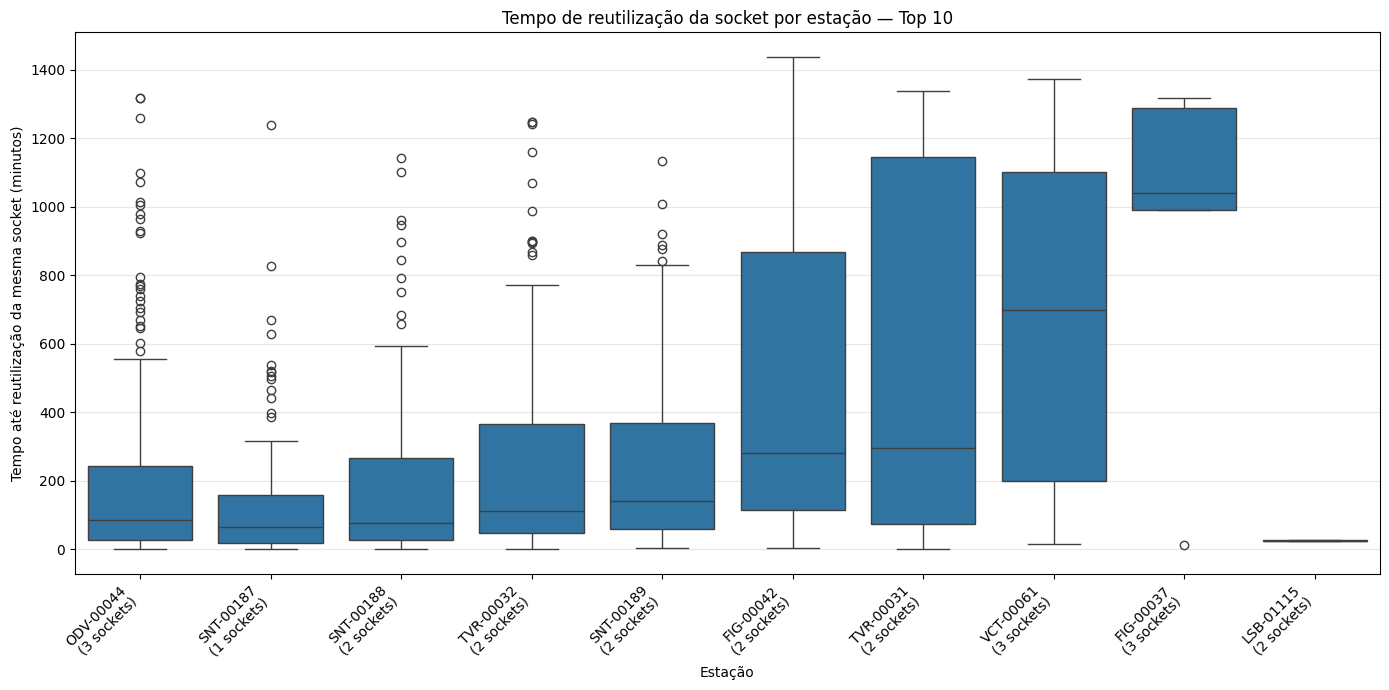

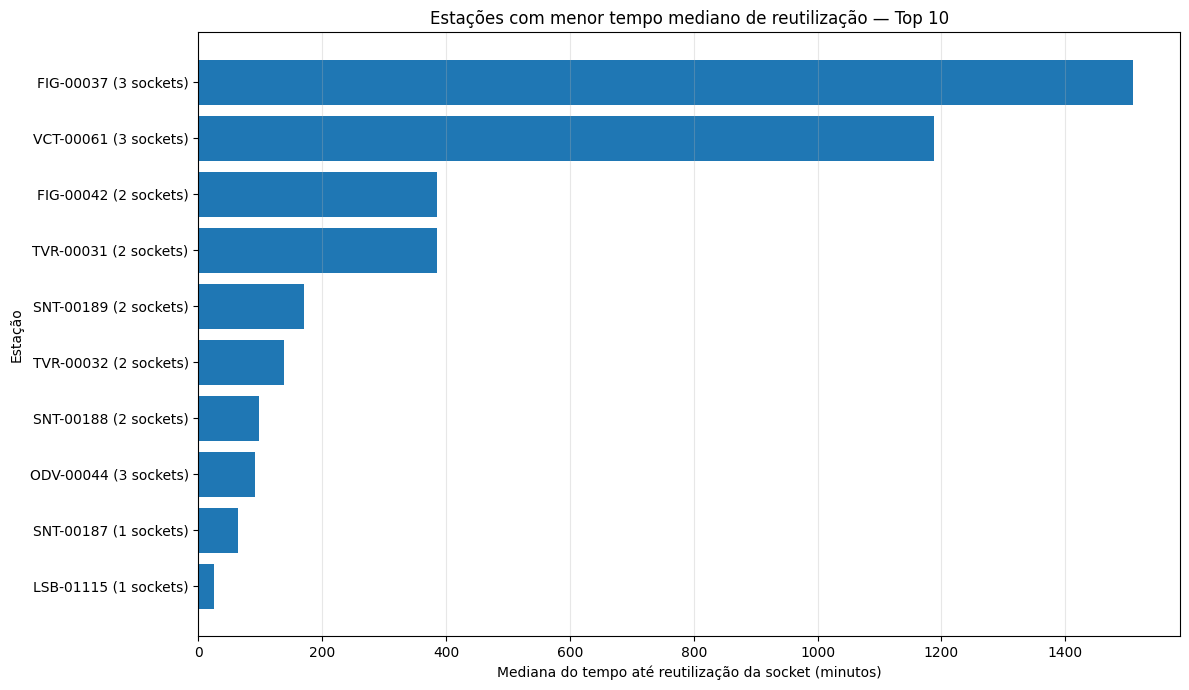


Ficheiros guardados:
- socket_reuse_events.csv
- socket_reuse_summary_by_station.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# Config
# =====================================================
CSV_PATH = "/home/joao-martins/Desktop/code/Enable Mobility/code/Enable/data/01_raw/detailed-20260116.csv"

MAX_MINUTES = 24 * 60      # show up to 24h
TOP_N_STATIONS = 10        # stations to compare in boxplot

# =====================================================
# Read CSV
# =====================================================
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=","
)

# =====================================================
# Parse timestamps
# =====================================================
df["startTimestamp"] = pd.to_datetime(
    df["startTimestamp"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df["stopTimestamp"] = pd.to_datetime(
    df["stopTimestamp"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

# Keep only valid rows
df = df.dropna(subset=[
    "idChargingStation",
    "idEVSE",
    "startTimestamp",
    "stopTimestamp"
]).copy()

# Remove impossible sessions
df = df[df["stopTimestamp"] >= df["startTimestamp"]].copy()

# =====================================================
# Socket-level reuse time
# =====================================================

# Very important:
# sort by socket, then by start time
df = df.sort_values([
    "idChargingStation",
    "idEVSE",
    "startTimestamp"
]).copy()

# For each socket, get the next session start
df["next_start_same_socket"] = (
    df.groupby(["idChargingStation", "idEVSE"])["startTimestamp"]
    .shift(-1)
)

# Reuse time:
# next car start time - previous car stop time
df["reuse_minutes"] = (
    df["next_start_same_socket"] - df["stopTimestamp"]
).dt.total_seconds() / 60

# Remove last session of each socket
reuse = df.dropna(subset=["reuse_minutes"]).copy()

# Keep only valid reuse times
# Negative means overlapping sessions in same EVSE,
# usually data issue or duplicated records
reuse = reuse[reuse["reuse_minutes"] >= 0].copy()

# =====================================================
# Number of sockets per station
# =====================================================
sockets_per_station = (
    df.groupby("idChargingStation")["idEVSE"]
    .nunique()
    .to_dict()
)

# =====================================================
# Summary table
# =====================================================
summary = (
    reuse.groupby("idChargingStation")
    .agg(
        n_reuse_events=("reuse_minutes", "count"),
        n_sockets=("idEVSE", "nunique"),
        mean_minutes=("reuse_minutes", "mean"),
        median_minutes=("reuse_minutes", "median"),
        p25_minutes=("reuse_minutes", lambda x: x.quantile(0.25)),
        p75_minutes=("reuse_minutes", lambda x: x.quantile(0.75)),
        p90_minutes=("reuse_minutes", lambda x: x.quantile(0.90)),
        max_minutes=("reuse_minutes", "max"),
    )
    .reset_index()
    .sort_values("n_reuse_events", ascending=False)
)

print("\nResumo por estação:")
print(summary)

# =====================================================
# 1. Overall distribution
# =====================================================
plot_reuse = reuse[reuse["reuse_minutes"] <= MAX_MINUTES].copy()

plt.figure(figsize=(10, 6))

plt.hist(
    plot_reuse["reuse_minutes"],
    bins=200,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("Tempo até a mesma socket voltar a ser usada (minutos)")
plt.ylabel("Número de ocorrências")
plt.title(f"Distribuição global do tempo de reutilização da socket (0–{MAX_MINUTES} min)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 2. Overall distribution in hours
# =====================================================
plot_reuse["reuse_hours"] = plot_reuse["reuse_minutes"] / 60

plt.figure(figsize=(10, 6))

plt.hist(
    plot_reuse["reuse_hours"],
    bins=200,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("Tempo até a mesma socket voltar a ser usada (horas)")
plt.ylabel("Número de ocorrências")
plt.title(f"Distribuição global do tempo de reutilização da socket (0–{MAX_MINUTES / 60:.0f}h)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 3. Boxplot by station
# =====================================================
top_stations = (
    reuse["idChargingStation"]
    .value_counts()
    .head(TOP_N_STATIONS)
    .index
)

station_plot = reuse[
    (reuse["idChargingStation"].isin(top_stations)) &
    (reuse["reuse_minutes"] <= MAX_MINUTES)
].copy()

station_order = list(top_stations)

station_labels = [
    f"{station}\n({sockets_per_station.get(station, 0)} sockets)"
    for station in station_order
]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=station_plot,
    x="idChargingStation",
    y="reuse_minutes",
    order=station_order
)

plt.xticks(
    ticks=range(len(station_order)),
    labels=station_labels,
    rotation=45,
    ha="right"
)

plt.xlabel("Estação")
plt.ylabel("Tempo até reutilização da mesma socket (minutos)")
plt.title(f"Tempo de reutilização da socket por estação — Top {TOP_N_STATIONS}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 4. Median reuse time by station
# =====================================================
median_by_station = (
    reuse.groupby("idChargingStation")
    .agg(
        median_minutes=("reuse_minutes", "median"),
        n_reuse_events=("reuse_minutes", "count"),
        n_sockets=("idEVSE", "nunique")
    )
    .reset_index()
    .sort_values("median_minutes")
)

median_by_station["label"] = median_by_station.apply(
    lambda row: f"{row['idChargingStation']} ({int(row['n_sockets'])} sockets)",
    axis=1
)

top_median_plot = median_by_station.head(TOP_N_STATIONS)

plt.figure(figsize=(12, 7))

plt.barh(
    top_median_plot["label"],
    top_median_plot["median_minutes"]
)

plt.xlabel("Mediana do tempo até reutilização da socket (minutos)")
plt.ylabel("Estação")
plt.title(f"Estações com menor tempo mediano de reutilização — Top {TOP_N_STATIONS}")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 5. Save results
# =====================================================
reuse.to_csv("socket_reuse_events.csv", index=False)
summary.to_csv("socket_reuse_summary_by_station.csv", index=False)

print("\nFicheiros guardados:")
print("- socket_reuse_events.csv")
print("- socket_reuse_summary_by_station.csv")

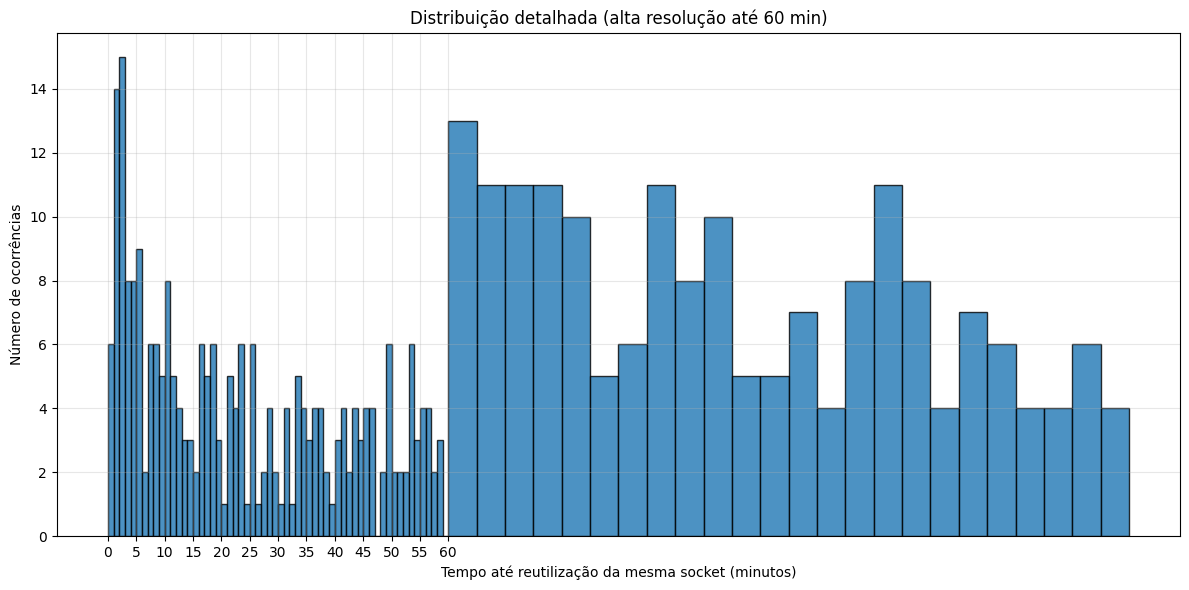

In [4]:

import numpy as np

# Focus region (you can tune this)
MAX_MINUTES = 180  # 3 hours

plot_reuse = reuse[reuse["reuse_minutes"] <= MAX_MINUTES].copy()

# ---------------------------------
# Custom bins:
# 0–60 min → 1 min bins
# 60–180 min → 5 min bins
# ---------------------------------
bins_fine = np.arange(0, 60, 1)
bins_coarse = np.arange(60, MAX_MINUTES + 5, 5)

bins = np.concatenate([bins_fine, bins_coarse])

plt.figure(figsize=(12, 6))

plt.hist(
    plot_reuse["reuse_minutes"],
    bins=bins,
    edgecolor="black",
    alpha=0.8
)

# Ticks every 5 minutes for clarity
plt.xticks(np.arange(0, 61, 5))

plt.xlabel("Tempo até reutilização da mesma socket (minutos)")
plt.ylabel("Número de ocorrências")
plt.title("Distribuição detalhada (alta resolução até 60 min)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

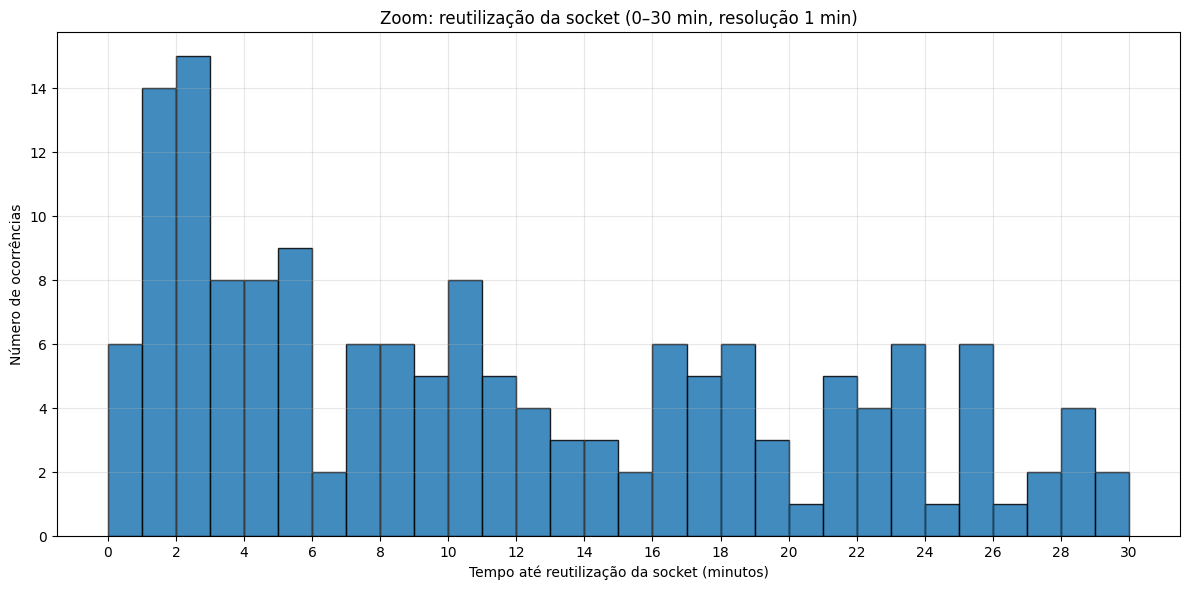

In [5]:
MAX_MINUTES = 30  # zoom HARD into the important region

plot_reuse = reuse[reuse["reuse_minutes"] <= MAX_MINUTES].copy()

bins = np.arange(0, MAX_MINUTES + 1, 1)  # 1-minute resolution

plt.figure(figsize=(12, 6))

plt.hist(
    plot_reuse["reuse_minutes"],
    bins=bins,
    edgecolor="black",
    alpha=0.85
)

plt.xticks(np.arange(0, MAX_MINUTES + 1, 2))  # every 2 minutes

plt.xlabel("Tempo até reutilização da socket (minutos)")
plt.ylabel("Número de ocorrências")
plt.title("Zoom: reutilização da socket (0–30 min, resolução 1 min)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

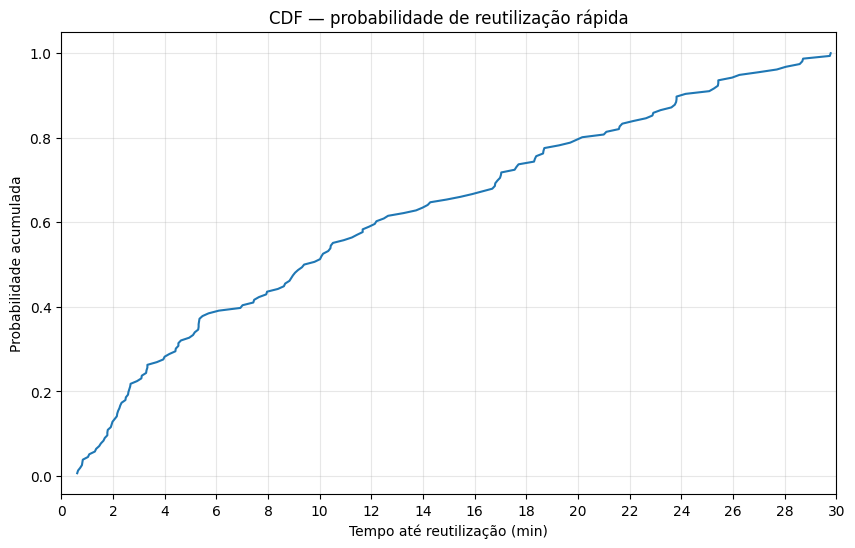

In [6]:
sorted_vals = np.sort(plot_reuse["reuse_minutes"])
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

plt.figure(figsize=(10, 6))

plt.plot(sorted_vals, cdf)

plt.xlim(0, 30)
plt.xticks(np.arange(0, 31, 2))

plt.xlabel("Tempo até reutilização (min)")
plt.ylabel("Probabilidade acumulada")
plt.title("CDF — probabilidade de reutilização rápida")

plt.grid(alpha=0.3)
plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_station_timeline(df, station_id, max_sockets=10):
    """
    Plot timeline of charging sessions for a given station.
    Each row is one EVSE (socket).
    """

    # Filter station
    station_df = df[df["idChargingStation"] == station_id].copy()

    if station_df.empty:
        print(f"No data for station {station_id}")
        return

    # Sort EVSEs
    evses = sorted(station_df["idEVSE"].unique())

    # Optional: limit sockets for readability
    evses = evses[:max_sockets]

    # Create mapping EVSE → y position
    evse_to_y = {evse: i for i, evse in enumerate(evses)}

    plt.figure(figsize=(20, 6))

    for _, row in station_df.iterrows():
        evse = row["idEVSE"]

        if evse not in evse_to_y:
            continue

        y = evse_to_y[evse]

        start = row["startTimestamp"]
        end = row["stopTimestamp"]

        plt.plot([start, end], [y, y], linewidth=6)

    plt.yticks(
        list(evse_to_y.values()),
        [f"{evse}" for evse in evses]
    )

    plt.xlabel("Tempo")
    plt.ylabel("Socket (EVSE)")
    plt.title(f"Timeline de carregamentos — Estação {station_id}")

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

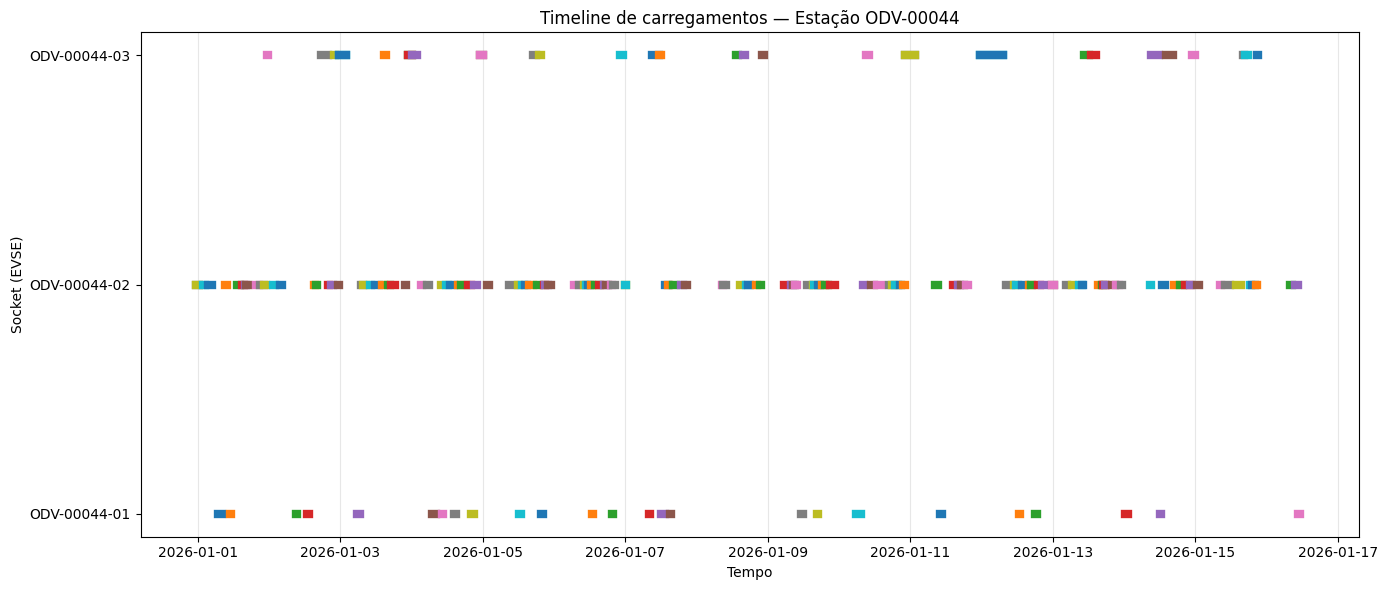

In [8]:
# Make sure timestamps are already parsed (same as before)

plot_station_timeline(df, station_id="ODV-00044")

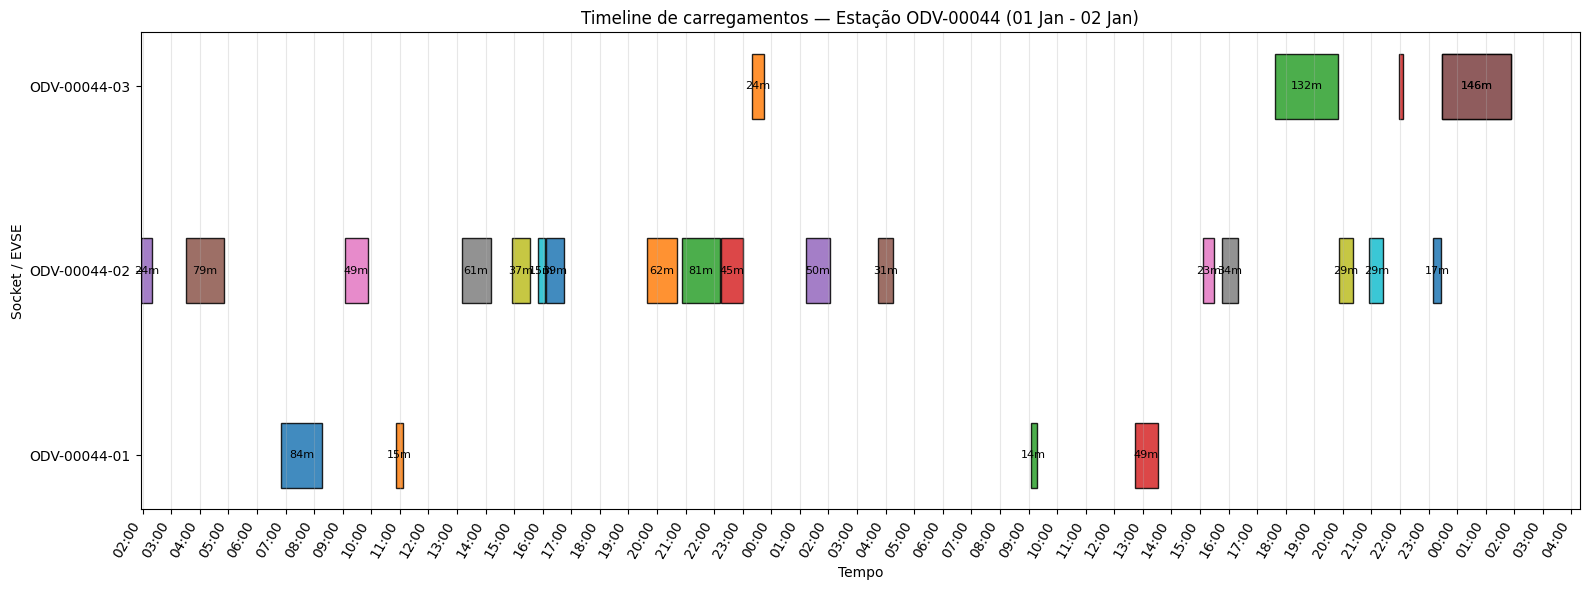

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =====================================================
# Config
# =====================================================
CSV_PATH = "/home/joao-martins/Desktop/code/Enable Mobility/code/Enable/data/01_raw/detailed-20260116.csv"

STATION_ID = "ODV-00044"
START_DATE = "2026-01-01"
END_DATE = "2026-01-03"   # exclusive, so this shows Jan 1 and Jan 2

# =====================================================
# Read data
# =====================================================
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=","
)

df["startTimestamp"] = pd.to_datetime(
    df["startTimestamp"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df["stopTimestamp"] = pd.to_datetime(
    df["stopTimestamp"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df = df.dropna(subset=[
    "idChargingStation",
    "idEVSE",
    "startTimestamp",
    "stopTimestamp"
]).copy()

df = df[df["stopTimestamp"] >= df["startTimestamp"]].copy()

# =====================================================
# Filter one station and one time window
# =====================================================
station_df = df[
    (df["idChargingStation"] == STATION_ID) &
    (df["startTimestamp"] >= pd.to_datetime(START_DATE)) &
    (df["startTimestamp"] < pd.to_datetime(END_DATE))
].copy()

station_df = station_df.sort_values(["idEVSE", "startTimestamp"])

# =====================================================
# Compute next start and reuse time per socket
# =====================================================
station_df["next_start_same_socket"] = (
    station_df.groupby("idEVSE")["startTimestamp"].shift(-1)
)

station_df["reuse_minutes"] = (
    station_df["next_start_same_socket"] - station_df["stopTimestamp"]
).dt.total_seconds() / 60

# =====================================================
# Plot
# =====================================================
evses = sorted(station_df["idEVSE"].unique())
evse_to_y = {evse: i for i, evse in enumerate(evses)}

fig, ax = plt.subplots(figsize=(16, 6))

for _, row in station_df.iterrows():
    y = evse_to_y[row["idEVSE"]]

    start = row["startTimestamp"]
    end = row["stopTimestamp"]

    duration_days = (end - start).total_seconds() / (24 * 3600)

    ax.barh(
        y=y,
        width=duration_days,
        left=start,
        height=0.35,
        edgecolor="black",
        alpha=0.85
    )

    # optional: write duration inside/near bar
    duration_min = (end - start).total_seconds() / 60
    if duration_min >= 10:
        ax.text(
            start + (end - start) / 2,
            y,
            f"{duration_min:.0f}m",
            ha="center",
            va="center",
            fontsize=8
        )

# Format y axis
ax.set_yticks(list(evse_to_y.values()))
ax.set_yticklabels(evses)

# Format x axis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_xlabel("Tempo")
ax.set_ylabel("Socket / EVSE")

ax.grid(axis="x", alpha=0.3)

start_str = pd.to_datetime(START_DATE).strftime("%d %b")
end_str = (pd.to_datetime(END_DATE) - pd.Timedelta(days=1)).strftime("%d %b")
ax.set_title(
    f"Timeline de carregamentos — Estação {STATION_ID} ({start_str} - {end_str})"
)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# =====================================================
# Config
# =====================================================
CSV_PATH = "/home/joao-martins/Desktop/code/Enable Mobility/code/Enable/data/01_raw/detailed-20260116.csv"

START_DATE = "2026-01-01"
END_DATE = "2026-01-03"   # exclusive

SAVE_PLOTS = True
OUTPUT_DIR = "station_timelines"

# =====================================================
# Read data
# =====================================================
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=","
)

df["startTimestamp"] = pd.to_datetime(
    df["startTimestamp"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df["stopTimestamp"] = pd.to_datetime(
    df["stopTimestamp"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df = df.dropna(subset=[
    "idChargingStation",
    "idEVSE",
    "startTimestamp",
    "stopTimestamp"
]).copy()

df = df[df["stopTimestamp"] >= df["startTimestamp"]].copy()

# =====================================================
# Filter time window
# =====================================================
start_dt = pd.to_datetime(START_DATE)
end_dt = pd.to_datetime(END_DATE)

df_window = df[
    (df["startTimestamp"] >= start_dt) &
    (df["startTimestamp"] < end_dt)
].copy()

# =====================================================
# Output folder
# =====================================================
if SAVE_PLOTS:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# =====================================================
# Function to plot one station
# =====================================================
def plot_station_timeline(station_df, station_id):
    station_df = station_df.sort_values(["idEVSE", "startTimestamp"]).copy()

    if station_df.empty:
        return

    station_df["next_start_same_socket"] = (
        station_df.groupby("idEVSE")["startTimestamp"].shift(-1)
    )

    station_df["reuse_minutes"] = (
        station_df["next_start_same_socket"] - station_df["stopTimestamp"]
    ).dt.total_seconds() / 60

    evses = sorted(station_df["idEVSE"].unique())
    evse_to_y = {evse: i for i, evse in enumerate(evses)}

    fig_height = max(4, len(evses) * 1.2)
    fig, ax = plt.subplots(figsize=(16, fig_height))

    for _, row in station_df.iterrows():
        y = evse_to_y[row["idEVSE"]]

        start = row["startTimestamp"]
        end = row["stopTimestamp"]

        duration_days = (end - start).total_seconds() / (24 * 3600)

        ax.barh(
            y=y,
            width=duration_days,
            left=start,
            height=0.35,
            edgecolor="black",
            alpha=0.85
        )

        duration_min = (end - start).total_seconds() / 60

        if duration_min >= 10:
            ax.text(
                start + (end - start) / 2,
                y,
                f"{duration_min:.0f}m",
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_yticks(list(evse_to_y.values()))
    ax.set_yticklabels(evses)

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

    ax.set_xlim(start_dt, end_dt)

    ax.set_xlabel("Tempo")
    ax.set_ylabel("Socket / EVSE")
    ax.grid(axis="x", alpha=0.3)

    start_str = start_dt.strftime("%d %b")
    end_str = (end_dt - pd.Timedelta(days=1)).strftime("%d %b")

    n_sockets = station_df["idEVSE"].nunique()
    n_sessions = len(station_df)

    ax.set_title(
        f"Timeline de carregamentos — Estação {station_id} "
        f"({start_str} - {end_str}) | "
        f"{n_sockets} sockets | {n_sessions} carregamentos"
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_station_id = str(station_id).replace("/", "_")
        output_path = Path(OUTPUT_DIR) / f"{safe_station_id}_timeline.png"
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

# =====================================================
# Plot all stations
# =====================================================
stations = sorted(df_window["idChargingStation"].unique())

print(f"Número de estações encontradas: {len(stations)}")

for station_id in stations:
    station_df = df_window[df_window["idChargingStation"] == station_id].copy()

    print(f"A gerar plot para {station_id}...")

    plot_station_timeline(station_df, station_id)

print("Concluído.")

Número de estações encontradas: 9
A gerar plot para FIG-00037...
A gerar plot para FIG-00042...
A gerar plot para ODV-00044...
A gerar plot para SNT-00187...
A gerar plot para SNT-00188...
A gerar plot para SNT-00189...
A gerar plot para TVR-00031...
A gerar plot para TVR-00032...
A gerar plot para VCT-00061...
Concluído.
